In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import numpy as np

In [ ]:
df = pd.read_parquet('../data_2024_otimizado.parquet')

In [4]:
mapeamento = {
    '1.b_genero': 'Gênero',
    '1.c_cor/raca/etnia': 'Cor/Etnia',
    '1.a_idade': 'Idade',
    '2.g_nivel': 'Nivel',
    '2.h_faixa_salarial': 'Salário',
    '2.i_tempo_de_experiencia_em_dados': 'Experiencia',
    '4.e_linguagem_mais_usada': 'Linguagem'
}

In [5]:
df_limpo = df[list(mapeamento.keys())].rename(columns=mapeamento)

In [6]:
df_limpo = df_limpo[df_limpo['Gênero'] != 'Prefiro não informar'].dropna()

In [7]:
print(f"Total de registros para análise: {len(df_limpo)}")
df_limpo.tail()

Total de registros para análise: 3414


,Gênero,Cor/Etnia,Idade,Nivel,Salário,Experiencia,Linguagem
5201,Masculino,Branca,60,Sênior,de R$ 8.001/mês a R$ 12.000/mês,de 5 a 6 anos,SQL
5203,Masculino,Branca,61,Sênior,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,SQL
5207,Masculino,Preta,63,Sênior,de R$ 25.001/mês a R$ 30.000/mês,de 7 a 10 anos,Python
5210,Masculino,Branca,64,Sênior,de R$ 30.001/mês a R$ 40.000/mês,Mais de 10 anos,Python
5213,Masculino,Branca,66,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 5 a 6 anos,R


In [9]:
ordem_salario = [
    'Menos de R$ 1.000/mês', 'de R$ 1.001/mês a R$ 2.000/mês', 
    'de R$ 2.001/mês a R$ 3.000/mês', 'de R$ 3.001/mês a R$ 4.000/mês',
    'de R$ 4.001/mês a R$ 6.000/mês', 'de R$ 6.001/mês a R$ 8.000/mês',
    'de R$ 8.001/mês a R$ 12.000/mês', 'de R$ 12.001/mês a R$ 16.000/mês',
    'de R$ 16.001/mês a R$ 20.000/mês', 'de R$ 20.001/mês a R$ 25.000/mês',
    'de R$ 25.001/mês a R$ 30.000/mês', 'de R$ 30.001/mês a R$ 40.000/mês',
    'Acima de R$ 40.001/mês'
]
ordem_nivel = ['Júnior', 'Pleno', 'Sênior']

In [10]:
mapa_salario = {label: i for i, label in enumerate(ordem_salario)}
mapa_nivel = {label: i for i, label in enumerate(ordem_nivel)}
mapa_genero = {'Masculino': 0, 'Feminino': 1, 'Outro': 2}

In [11]:
df_limpo['Salario_Num'] = df_limpo['Salário'].map(mapa_salario)
df_limpo['Nivel_Num'] = df_limpo['Nivel'].map(mapa_nivel)
df_limpo['Genero_Num'] = df_limpo['Gênero'].map(mapa_genero)

In [12]:
df_limpo = df_limpo.dropna(subset=['Salario_Num', 'Nivel_Num', 'Genero_Num'])

In [13]:
print(f"Dados prontos! Total de registros: {len(df_limpo)}")

Dados prontos! Total de registros: 3414


In [19]:
# 1. Definir Atributos (X) e Alvo (y)
X = df_limpo[['Genero_Num', 'Nivel_Num']]
y = df_limpo['Salario_Num']

# 2. Divisão 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Treinar Árvore de Decisão
modelo_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_tree.fit(X_train, y_train)

# --- AUDITORIA DE VIÉS ---
# Separar o grupo de teste para ver onde a IA erra mais
teste_mulheres = X_test[X_test['Genero_Num'] == 1]
teste_homens = X_test[X_test['Genero_Num'] == 0]
teste_outros = X_test[X_test['Genero_Num']== 2]

acc_mulheres = accuracy_score(y_test.loc[teste_mulheres.index], modelo_tree.predict(teste_mulheres))
acc_homens = accuracy_score(y_test.loc[teste_homens.index], modelo_tree.predict(teste_homens))
acc_outros = accuracy_score(y_test.loc[teste_outros.index], modelo_tree.predict(teste_outros))

print(f"📊 Acurácia em Mulheres: {acc_mulheres:.2%}")
print(f"📊 Acurácia em Homens: {acc_homens:.2%}")
print(f"Teste acurácia em outros: {acc_outros:.2%}")

if acc_homens > acc_mulheres:
    print(f"⚠️ Alerta: O modelo é {acc_homens - acc_mulheres:.2%} mais preciso para homens do que para mulheres.")

📊 Acurácia em Mulheres: 36.93%
📊 Acurácia em Homens: 29.03%
Teste acurácia em outros: 50.00%


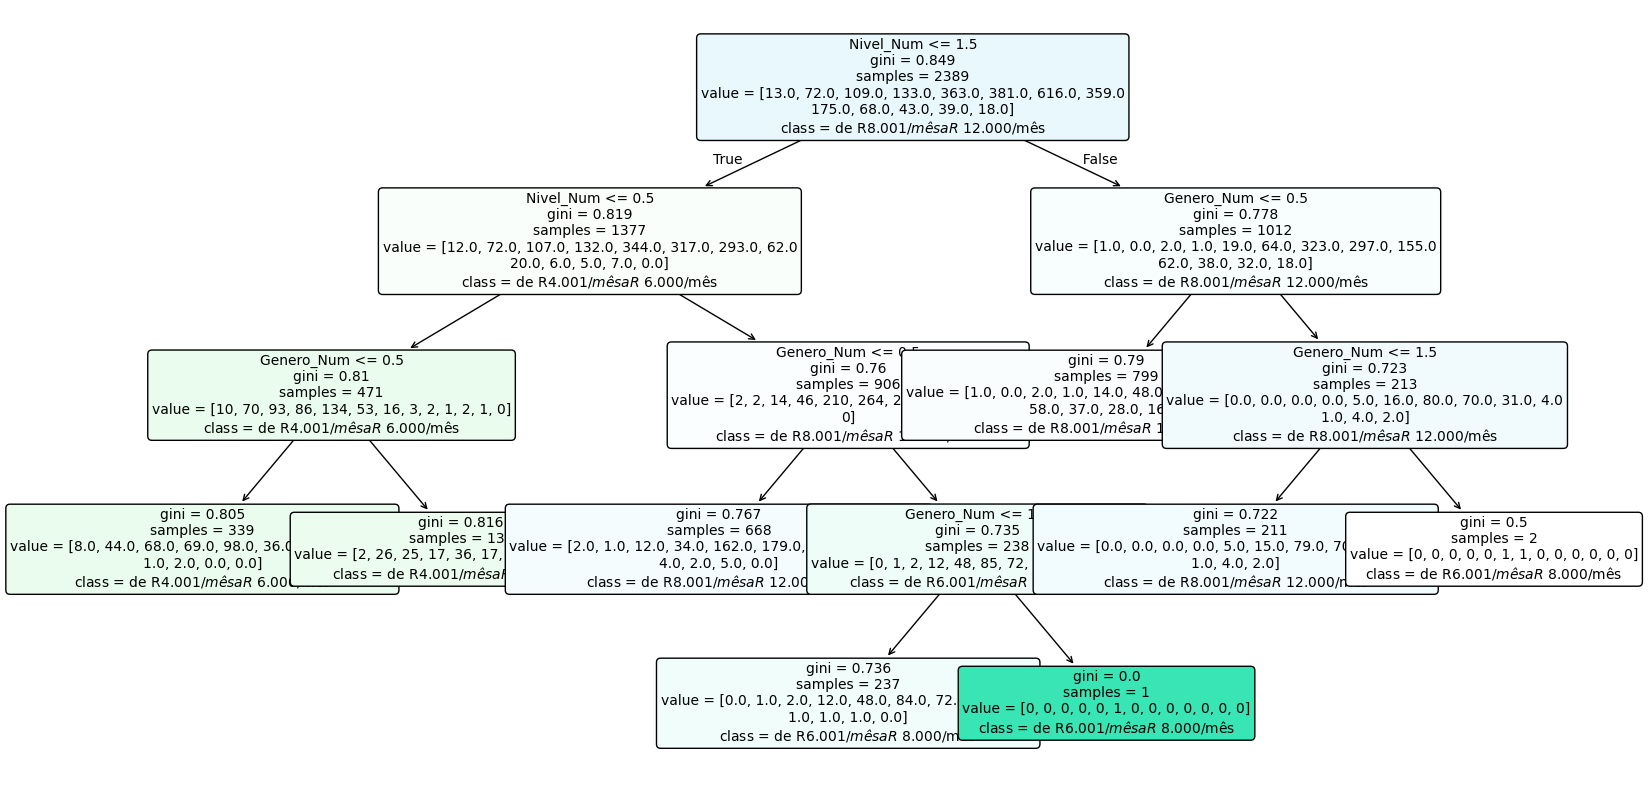

In [28]:
plt.figure(figsize=(20,10))
plot_tree(modelo_tree, 
          feature_names=X.columns, 
          class_names=[str(i) for i in ordem_salario], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()


--- Relatório: Geral ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00        30
           2       0.00      0.00      0.00        45
           3       0.00      0.00      0.00        64
           4       0.29      0.44      0.35       146
           5       0.28      0.15      0.19       171
           6       0.32      0.81      0.46       280
           7       0.00      0.00      0.00       156
           8       0.00      0.00      0.00        64
           9       0.00      0.00      0.00        22
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        17
          12       0.00      0.00      0.00        12

    accuracy                           0.31      1025
   macro avg       0.07      0.11      0.08      1025
weighted avg       0.18      0.31      0.21      1025



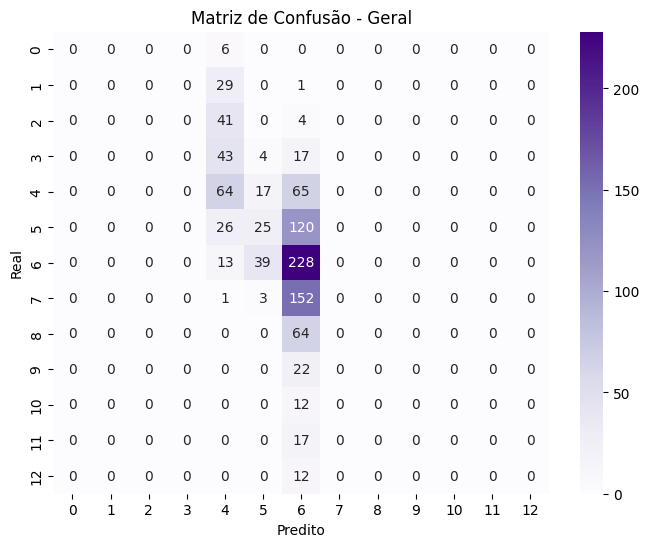


--- Relatório: Apenas Mulheres ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00        13
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        11
           4       0.32      0.53      0.40        36
           5       0.28      0.55      0.37        44
           6       0.48      0.53      0.51        86
           7       0.00      0.00      0.00        28
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         1

    accuracy                           0.37       241
   macro avg       0.10      0.15      0.12       241
weighted avg       0.27      0.37      0.31       241



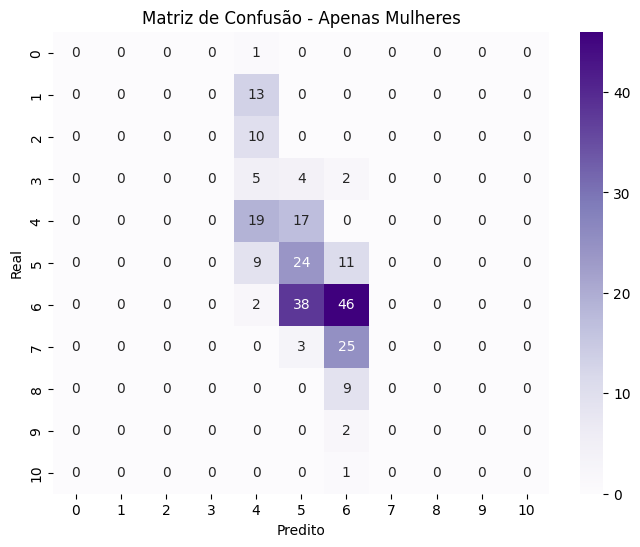


--- Relatório: Apenas Homens ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00        17
           2       0.00      0.00      0.00        35
           3       0.00      0.00      0.00        53
           4       0.27      0.41      0.33       110
           5       0.00      0.00      0.00       126
           6       0.29      0.94      0.45       193
           7       0.00      0.00      0.00       128
           8       0.00      0.00      0.00        55
           9       0.00      0.00      0.00        20
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        16
          12       0.00      0.00      0.00        12

    accuracy                           0.29       782
   macro avg       0.04      0.10      0.06       782
weighted avg       0.11      0.29      0.16       782



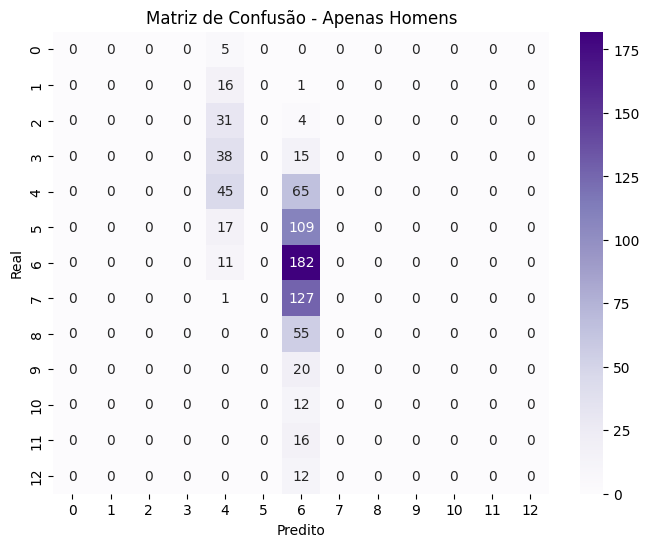


--- Relatório: Apenas Outro ---
              precision    recall  f1-score   support

           5       0.50      1.00      0.67         1
           6       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



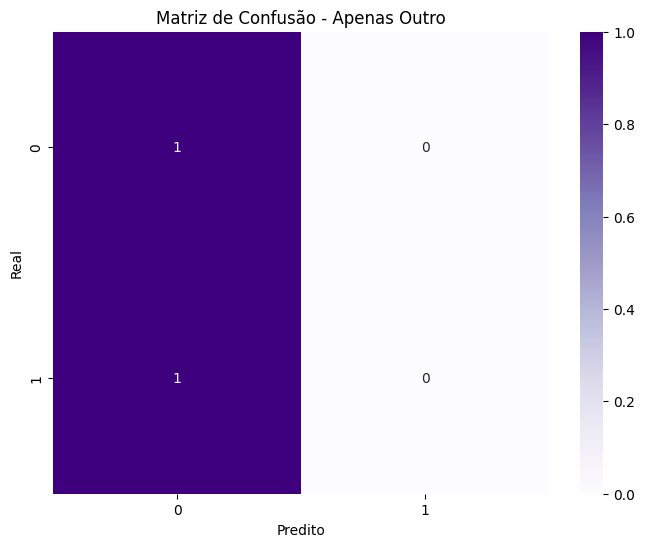

In [ ]:
def auditoria_completa(X_subset, y_subset, titulo):
    y_pred_sub = modelo_tree.predict(X_subset)
    
    print(f"\n--- Relatório: {titulo} ---")
    print(classification_report(y_subset, y_pred_sub, zero_division=0))
    
    # Matriz de Confusão
    cm = confusion_matrix(y_subset, y_pred_sub)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title(f'Matriz de Confusão - {titulo}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

# Rodar para os 4 casos
auditoria_completa(X_test, y_test, "Geral")
auditoria_completa(teste_mulheres, y_test.loc[teste_mulheres.index], "Apenas Mulheres")
auditoria_completa(teste_homens, y_test.loc[teste_homens.index], "Apenas Homens")
auditoria_completa(teste_outros, y_test.loc[teste_outros.index], "Apenas Outro")

--- RESULTADOS: REGRESSÃO LOGÍSTICA ---

--- Relatório: Geral - Logística ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00        30
           2       0.00      0.00      0.00        45
           3       0.00      0.00      0.00        64
           4       0.29      0.44      0.35       146
           5       0.28      0.15      0.19       171
           6       0.32      0.81      0.46       280
           7       0.00      0.00      0.00       156
           8       0.00      0.00      0.00        64
           9       0.00      0.00      0.00        22
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        17
          12       0.00      0.00      0.00        12

    accuracy                           0.31      1025
   macro avg       0.07      0.11      0.08      1025
weighted avg       0.18      0.31      0.21      1025



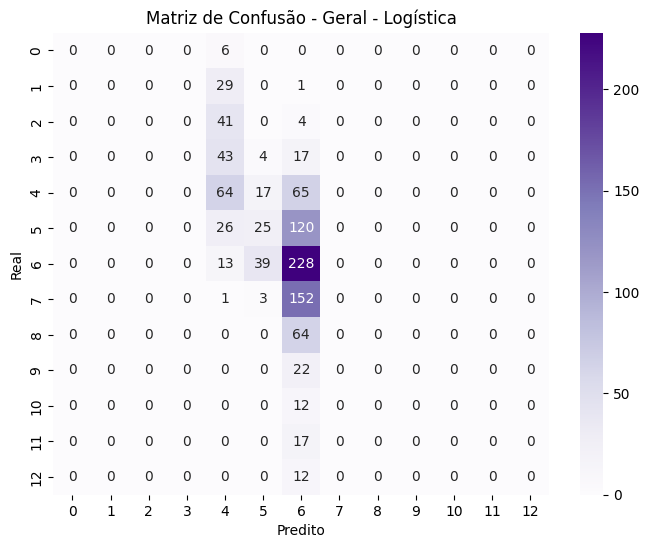


--- Relatório: Mulheres - Logística ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00        13
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        11
           4       0.32      0.53      0.40        36
           5       0.28      0.55      0.37        44
           6       0.48      0.53      0.51        86
           7       0.00      0.00      0.00        28
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         1

    accuracy                           0.37       241
   macro avg       0.10      0.15      0.12       241
weighted avg       0.27      0.37      0.31       241



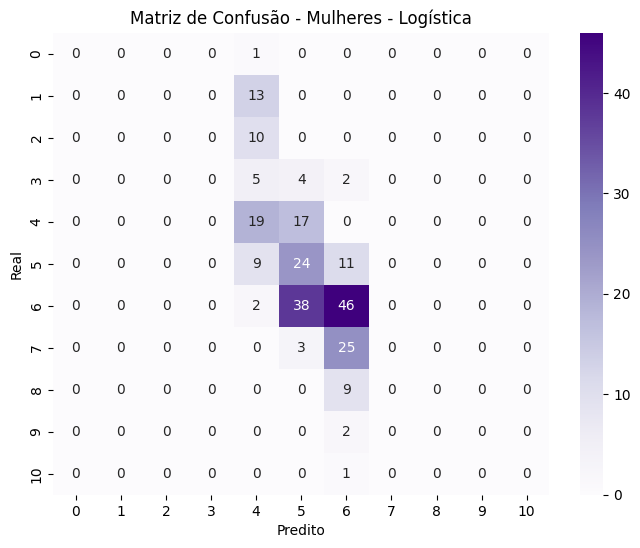


--- Relatório: Homens - Logística ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00        17
           2       0.00      0.00      0.00        35
           3       0.00      0.00      0.00        53
           4       0.27      0.41      0.33       110
           5       0.00      0.00      0.00       126
           6       0.29      0.94      0.45       193
           7       0.00      0.00      0.00       128
           8       0.00      0.00      0.00        55
           9       0.00      0.00      0.00        20
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        16
          12       0.00      0.00      0.00        12

    accuracy                           0.29       782
   macro avg       0.04      0.10      0.06       782
weighted avg       0.11      0.29      0.16       782



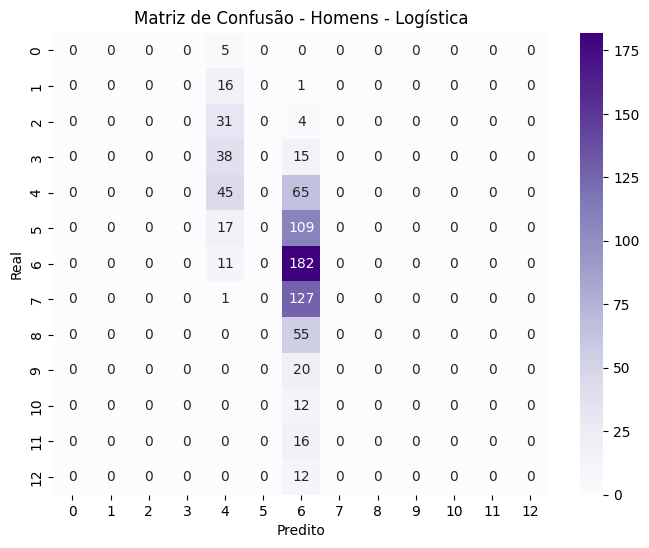

In [ ]:
# Criar o modelo de Regressão Logística

modelo_log = LogisticRegression(max_iter=1000, random_state=42)

# Treinar (usando os mesmos dados de treino da árvore)
modelo_log.fit(X_train, y_train)

# Rodar a auditoria para comparar
print("--- RESULTADOS: REGRESSÃO LOGÍSTICA ---")
auditoria_completa(X_test, y_test, "Geral - Logística")
auditoria_completa(teste_mulheres, y_test.loc[teste_mulheres.index], "Mulheres - Logística")
auditoria_completa(teste_homens, y_test.loc[teste_homens.index], "Homens - Logística")

In [23]:
# Pegamos os coeficientes da primeira classe de salário como exemplo
importancia = modelo_log.coef_[0] 
features = X.columns

for i, v in enumerate(importancia):
    print(f'Variável: {features[i]}, Peso: {v:.4f}')

Variável: Genero_Num, Peso: -0.2672
Variável: Nivel_Num, Peso: -2.1164


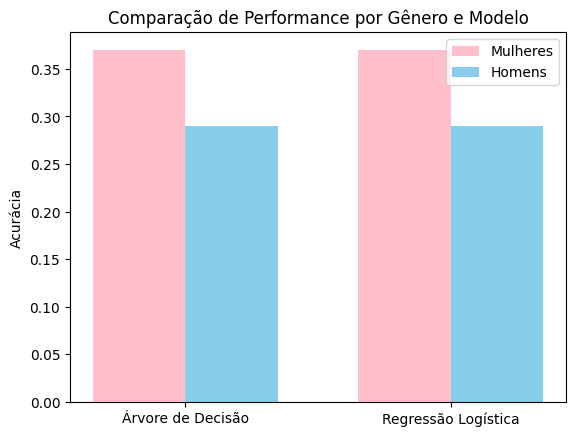

In [24]:
modelos = ['Árvore de Decisão', 'Regressão Logística']
acc_mulheres_total = [0.3693, 0.37] # Substitua pelos seus valores exatos
acc_homens_total = [0.2903, 0.29]   # Substitua pelos seus valores exatos

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, acc_mulheres_total, width, label='Mulheres', color='pink')
rects2 = ax.bar(x + width/2, acc_homens_total, width, label='Homens', color='skyblue')

ax.set_ylabel('Acurácia')
ax.set_title('Comparação de Performance por Gênero e Modelo')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()

plt.show()

In [ ]:

# Vamos manter os originais e apenas agrupar para a análise
df_analise = df.copy()

# Criar a coluna numérica de salário para podermos calcular a média

mapa_salario = {label: i for i, label in enumerate(ordem_salario)}
df_analise['Salario_Num'] = df['2.h_faixa_salarial'].map(mapa_salario)

# Calcular a média salarial por gênero (incluindo quem não informou)
comparativo = df_analise.groupby('1.b_genero')['Salario_Num'].mean().sort_values(ascending=False)

print("--- Média de Faixa Salarial por Gênero ---")
print(comparativo)

# Cálculo extra: Percentual de 'Prefiro não informar' em cargos altos
# (Para ver se eles estão no topo da pirâmide)
gestores_omissos = df_analise[(df_analise['2.g_nivel'] == 'Gestão') & 
                              (df_analise['1.b_genero'] == 'Prefiro não informar')].shape[0]


--- Média de Faixa Salarial por Gênero ---
1.b_genero
Outro                   6.500000
Prefiro não informar    6.266667
Masculino               6.112162
Feminino                5.492995
Name: Salario_Num, dtype: float64
